# Silver Databridge — Segmented Random Forest
**Target:** `default_12m` (binary: 0 = no default, 1 = default)

**Key idea:** A single global model applies the same feature weights to every customer. Here we train **one Random Forest per `(customer_segment, industry_sector)` combination** — 42 submodels in total — so each one learns the feature importances that matter for *that specific group*.

Pipeline:
1. Load & inspect
2. Preprocessing & encoding
3. Segment-aware stratified train/test split
4. Train one RF per group
5. Aggregate evaluation (classification report, ROC-AUC)
6. Compare feature importances across segments
7. Predict on new data (helper function)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

## 1. Load & Inspect

In [2]:
df = pd.read_csv('../data/bronze/bronze_databridge.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (30000, 62)


,application_id,source_system,ocr_engine,doc_type,page_count,file_size_kb,image_blur,skew_angle_deg,document_image_quality,ocr_confidence,...,credit_requested_value,income_declared,tenure_months,collateral_type,ltv,pd_model_score,final_decision,reason_code,requires_human_review,default_12m
0,APP-20260000001,OCR_PDF,azure_ocr,EXTRATO,1,1421.0,0.140,-1.35,0.821,0.562,...,10898.86,53421.80,210,IMOVEL,0.67,0.297,APPROVE,OK,1,0
1,APP-20260000002,OCR_PDF,tesseract,RG,9,1556.0,0.016,0.50,0.968,0.689,...,19605.00,22433.06,125,IMOVEL,1.63,0.346,REVIEW,HIGH_RISK,1,0
2,APP-20260000003,EMAIL_ATTACH,google_vision,EXTRATO,8,982.0,0.338,1.80,0.622,0.830,...,26290.89,28138.01,152,VEICULO,0.67,0.223,APPROVE,OK,0,1


In [3]:
print('customer_segment distribution:')
print(df['customer_segment'].value_counts().to_frame('count'))
print('\nindustry_sector distribution:')
print(df['industry_sector'].value_counts().to_frame('count'))
print(f'\nTotal (segment, sector) groups: {df.groupby(["customer_segment","industry_sector"]).ngroups}')

customer_segment distribution:
                  count
customer_segment       
PJ_ME              4367
AGRO_PEQUENO       4307
AGRO_GRANDE        4301
AGRO_MEDIO         4289
PJ_EPP             4279
PJ_GRANDE          4268
PF                 4189

industry_sector distribution:
                 count
industry_sector       
GOVERNO           5066
SERVICOS          5030
COMERCIO          5025
INDUSTRIA         4997
PF                4944
RURAL             4938

Total (segment, sector) groups: 42


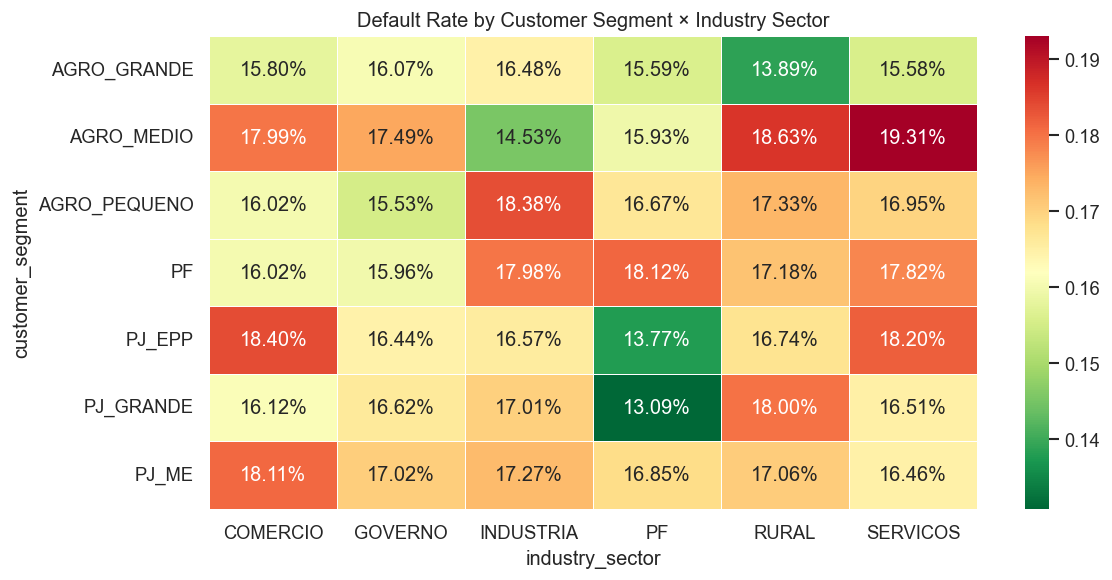

In [4]:
# Default rate heatmap — shows why a single model is insufficient
default_rates = (
    df.groupby(['customer_segment', 'industry_sector'])['default_12m']
    .mean()
    .reset_index()
    .pivot(index='customer_segment', columns='industry_sector', values='default_12m')
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(default_rates, annot=True, fmt='.2%', cmap='RdYlGn_r', ax=ax, linewidths=0.5)
ax.set_title('Default Rate by Customer Segment × Industry Sector')
plt.tight_layout()
plt.show()

## 2. Preprocessing & Encoding

In [5]:
TARGET     = 'default_12m'
GROUP_COLS = ['customer_segment', 'industry_sector']

# Drop leakage / pipeline-artifact columns
# - normalized_date      : raw date string, not useful without parsing
# - is_duplicate         : data-pipeline flag, not a real feature
# - final_decision       : decided after default is observed (leakage)
# - requires_human_review: post-hoc pipeline flag
DROP_COLS = ['normalized_date', 'is_duplicate', 'final_decision', 'requires_human_review']

df_clean = df.drop(columns=[c for c in DROP_COLS if c in df.columns]).copy()

# Label-encode all categoricals EXCEPT the group columns
# (encode on full dataset so all submodels share the same integer mapping)
cat_cols = [
    c for c in df_clean.select_dtypes(include=['object', 'str']).columns
    if c not in GROUP_COLS
]
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    encoders[col] = le

# Stash original string labels for grouping (they were encoded above)
df_clean['_seg'] = df['customer_segment']
df_clean['_sec'] = df['industry_sector']

# Features each submodel sees: everything except target and group identifiers
FEATURE_COLS = [
    c for c in df_clean.columns
    if c not in [TARGET] + GROUP_COLS + ['_seg', '_sec']
]

print(f'Features per submodel : {len(FEATURE_COLS)}')
print(f'Group columns (routing only): {GROUP_COLS}')
print(FEATURE_COLS)

Features per submodel : 56
Group columns (routing only): ['customer_segment', 'industry_sector']
['application_id', 'source_system', 'ocr_engine', 'doc_type', 'page_count', 'file_size_kb', 'image_blur', 'skew_angle_deg', 'document_image_quality', 'ocr_confidence', 'ocr_error_count', 'raw_amount_text', 'raw_date_text', 'free_text', 'text_language', 'normalized_amount', 'normalization_method', 'ingest_batch_id', 'version', 'created_at', 'updated_at', 'match_score', 'join_status', 'master_id', 'uf', 'regiao', 'duplicate_group_id', 'data_quality_score', 'rule_violations', 'pii_detected', 'compliance_status', 'lineage_path', 'checksum', 'retention_class', 'bioma', 'lat', 'lon', 'precip_mm_30d', 'temp_c_mean_30d', 'drought_spi', 'flood_risk_idx', 'ndvi', 'soil_moisture', 'fire_hotspots_30d', 'deforestation_km2_12m', 'climate_alert_level', 'days_rain_30d', 'wind_speed_mean', 'humidity_mean', 'credit_requested_value', 'income_declared', 'tenure_months', 'collateral_type', 'ltv', 'pd_model_scor

## 3. Segment-Aware Train / Test Split
Split **within** each group so every submodel has its own held-out test rows at the same 80/20 ratio.

In [6]:
train_parts, test_parts = [], []

for (seg, sec), grp in df_clean.groupby(['_seg', '_sec']):
    if grp[TARGET].nunique() < 2:
        # Edge case: only one class — keep all rows in train, skip test
        train_parts.append(grp)
        continue
    tr, te = train_test_split(grp, test_size=0.2, random_state=42, stratify=grp[TARGET])
    train_parts.append(tr)
    test_parts.append(te)

df_train = pd.concat(train_parts).reset_index(drop=True)
df_test  = pd.concat(test_parts).reset_index(drop=True)

print(f'Train : {len(df_train):,} rows | default rate: {df_train[TARGET].mean():.2%}')
print(f'Test  : {len(df_test):,}  rows | default rate: {df_test[TARGET].mean():.2%}')

Train : 23,980 rows | default rate: 16.71%
Test  : 6,020  rows | default rate: 16.63%


## 4. Train One Random Forest per (Segment, Sector)

Each submodel independently learns which features drive defaults for *its* group.
Using `class_weight='balanced'` handles the ~83/17 class imbalance within each subgroup.

In [7]:
RF_PARAMS = dict(
    n_estimators=300,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

models      = {}  # (seg, sec) -> fitted RandomForestClassifier
importances = {}  # (seg, sec) -> pd.Series of feature importances

groups = list(df_train.groupby(['_seg', '_sec']))
print(f'Training {len(groups)} submodels...\n')

for (seg, sec), grp in groups:
    X_tr = grp[FEATURE_COLS]
    y_tr = grp[TARGET]

    if y_tr.nunique() < 2:
        print(f'  SKIP ({seg}, {sec}): only one class in training data')
        continue

    rf = RandomForestClassifier(**RF_PARAMS)
    rf.fit(X_tr, y_tr)

    models[(seg, sec)]      = rf
    importances[(seg, sec)] = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
    print(f'  ok  [{seg:15s} | {sec:10s}]  n_train={len(grp)}')

print(f'\nDone. {len(models)} submodels trained.')

Training 42 submodels...

  ok  [AGRO_GRANDE     | COMERCIO  ]  n_train=567
  ok  [AGRO_GRANDE     | GOVERNO   ]  n_train=557
  ok  [AGRO_GRANDE     | INDUSTRIA ]  n_train=582
  ok  [AGRO_GRANDE     | PF        ]  n_train=569
  ok  [AGRO_GRANDE     | RURAL     ]  n_train=599
  ok  [AGRO_GRANDE     | SERVICOS  ]  n_train=564
  ok  [AGRO_MEDIO      | COMERCIO  ]  n_train=604
  ok  [AGRO_MEDIO      | GOVERNO   ]  n_train=585
  ok  [AGRO_MEDIO      | INDUSTRIA ]  n_train=572
  ok  [AGRO_MEDIO      | PF        ]  n_train=542
  ok  [AGRO_MEDIO      | RURAL     ]  n_train=549
  ok  [AGRO_MEDIO      | SERVICOS  ]  n_train=576
  ok  [AGRO_PEQUENO    | COMERCIO  ]  n_train=559
  ok  [AGRO_PEQUENO    | GOVERNO   ]  n_train=623
  ok  [AGRO_PEQUENO    | INDUSTRIA ]  n_train=600
  ok  [AGRO_PEQUENO    | PF        ]  n_train=532
  ok  [AGRO_PEQUENO    | RURAL     ]  n_train=563
  ok  [AGRO_PEQUENO    | SERVICOS  ]  n_train=566
  ok  [PF              | COMERCIO  ]  n_train=559
  ok  [PF              |

## 5. Aggregate Evaluation

In [8]:
all_true, all_pred, all_proba = [], [], []
segment_metrics = []

for (seg, sec), rf in models.items():
    te = df_test[(df_test['_seg'] == seg) & (df_test['_sec'] == sec)]
    if len(te) == 0 or te[TARGET].nunique() < 2:
        continue

    y_true = te[TARGET]
    y_pred  = rf.predict(te[FEATURE_COLS])
    y_proba = rf.predict_proba(te[FEATURE_COLS])[:, 1]

    auc = roc_auc_score(y_true, y_proba)
    segment_metrics.append({
        'segment': seg, 'sector': sec,
        'n_test': len(te),
        'default_rate': y_true.mean(),
        'roc_auc': auc
    })

    all_true.extend(y_true)
    all_pred.extend(y_pred)
    all_proba.extend(y_proba)

all_true  = np.array(all_true)
all_pred  = np.array(all_pred)
all_proba = np.array(all_proba)

print('=== Overall Classification Report (all 42 submodels) ===')
print(classification_report(all_true, all_pred, target_names=['No Default', 'Default']))
print(f'Overall ROC-AUC: {roc_auc_score(all_true, all_proba):.4f}')

=== Overall Classification Report (all 42 submodels) ===
              precision    recall  f1-score   support

  No Default       0.83      1.00      0.91      5019
     Default       0.00      0.00      0.00      1001

    accuracy                           0.83      6020
   macro avg       0.42      0.50      0.45      6020
weighted avg       0.69      0.83      0.76      6020

Overall ROC-AUC: 0.5437


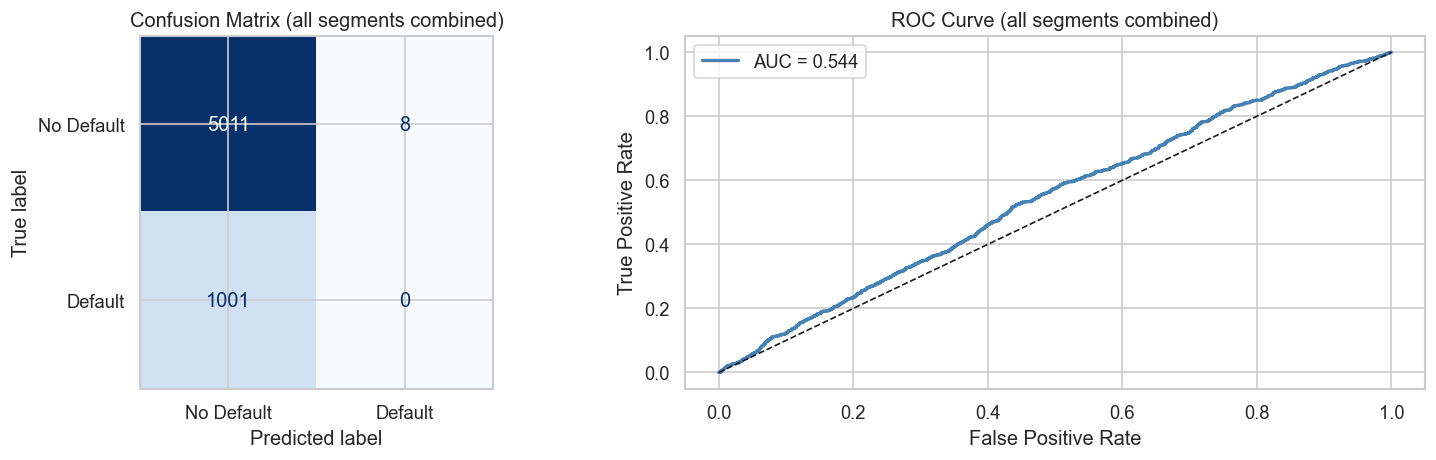

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
cm = confusion_matrix(all_true, all_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (all segments combined)')

# ROC Curve
fpr, tpr, _ = roc_curve(all_true, all_proba)
auc_val = roc_auc_score(all_true, all_proba)
axes[1].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc_val:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (all segments combined)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# Per-segment AUC table
metrics_df = (
    pd.DataFrame(segment_metrics)
    .sort_values('roc_auc', ascending=False)
    .reset_index(drop=True)
    .assign(
        default_rate=lambda d: d['default_rate'].map('{:.1%}'.format),
        roc_auc=lambda d: d['roc_auc'].map('{:.3f}'.format)
    )
)
print('Per-group ROC-AUC:')
metrics_df

Per-group ROC-AUC:


,segment,sector,n_test,default_rate,roc_auc
0,AGRO_PEQUENO,PF,134,16.4%,0.677
1,AGRO_GRANDE,GOVERNO,140,15.7%,0.636
2,AGRO_MEDIO,SERVICOS,144,19.4%,0.608
3,PJ_GRANDE,SERVICOS,147,16.3%,0.604
4,AGRO_MEDIO,COMERCIO,152,17.8%,0.600
5,PJ_ME,PF,145,16.6%,0.599
6,PF,COMERCIO,140,15.7%,0.598
7,PJ_GRANDE,COMERCIO,147,16.3%,0.593
8,PJ_ME,GOVERNO,140,17.1%,0.577
9,PJ_ME,INDUSTRIA,150,17.3%,0.574


## Global RF Baseline
Train a single Random Forest on **all** rows (same `df_train` / `df_test` split used by the segmented models) to establish a global baseline for comparison.

Global RF training complete.

=== Global RF — Classification Report ===
              precision    recall  f1-score   support

  No Default       0.83      1.00      0.91      5019
     Default       0.00      0.00      0.00      1001

    accuracy                           0.83      6020
   macro avg       0.42      0.50      0.45      6020
weighted avg       0.70      0.83      0.76      6020

ROC-AUC : 0.5658


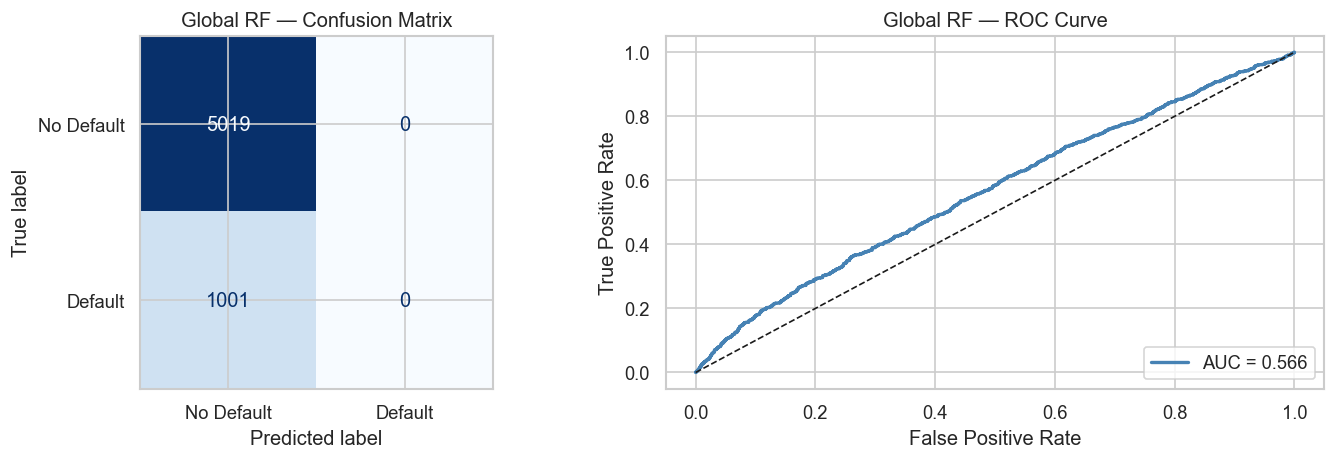

In [11]:
X_train_g = df_train[FEATURE_COLS]
y_train_g = df_train[TARGET]
X_test_g  = df_test[FEATURE_COLS]
y_test_g  = df_test[TARGET]

rf_global = RandomForestClassifier(**RF_PARAMS)
rf_global.fit(X_train_g, y_train_g)
print('Global RF training complete.')

y_pred_g  = rf_global.predict(X_test_g)
y_proba_g = rf_global.predict_proba(X_test_g)[:, 1]

print('\n=== Global RF — Classification Report ===')
print(classification_report(y_test_g, y_pred_g, target_names=['No Default', 'Default']))
print(f'ROC-AUC : {roc_auc_score(y_test_g, y_proba_g):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm_g = confusion_matrix(y_test_g, y_pred_g)
ConfusionMatrixDisplay(cm_g, display_labels=['No Default', 'Default']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Global RF — Confusion Matrix')

fpr_g, tpr_g, _ = roc_curve(y_test_g, y_proba_g)
auc_g = roc_auc_score(y_test_g, y_proba_g)
axes[1].plot(fpr_g, tpr_g, color='steelblue', lw=2, label=f'AUC = {auc_g:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Global RF — ROC Curve')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

## Comparison: Global RF vs Segmented RF
Side-by-side metrics to quantify whether per-group specialisation improves over the single global model.
Both models are evaluated on the same held-out test rows.

                     Global RF  Segmented RF  Delta (Seg − Global)
ROC-AUC                 0.5658        0.5437               -0.0221
F1 (Default)            0.0000        0.0000                0.0000
Precision (Default)     0.0000        0.0000                0.0000
Recall (Default)        0.0000        0.0000                0.0000


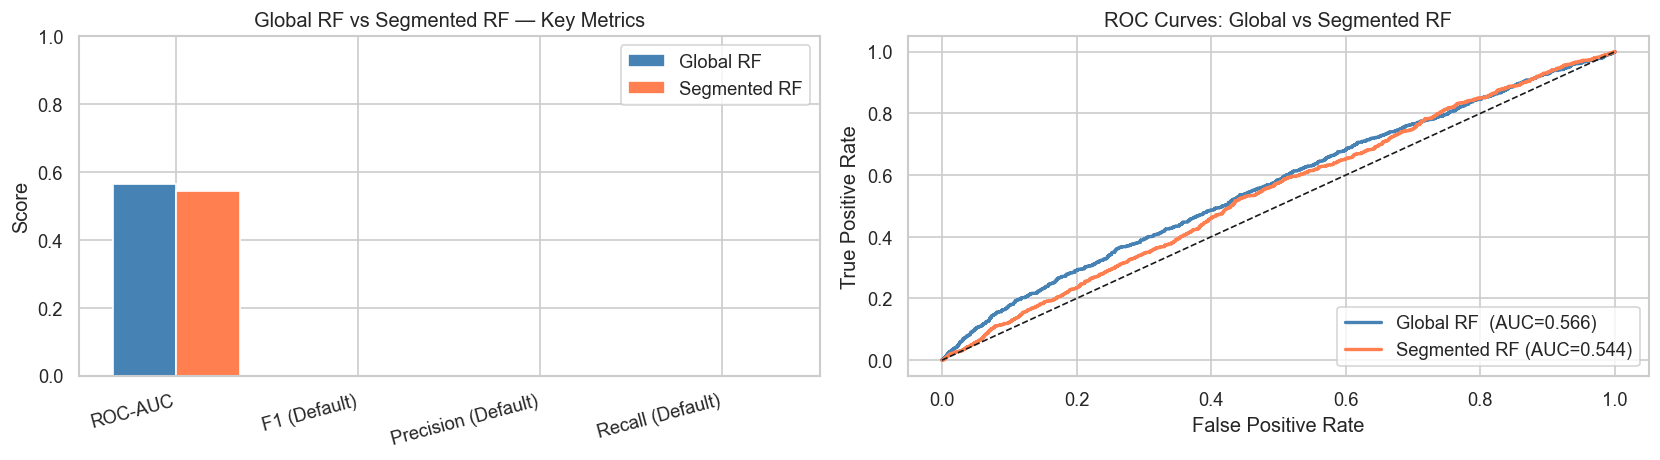

In [12]:
from sklearn.metrics import f1_score, precision_score, recall_score

metrics = {
    'ROC-AUC':             [roc_auc_score(y_test_g, y_proba_g), roc_auc_score(all_true, all_proba)],
    'F1 (Default)':        [f1_score(y_test_g, y_pred_g, zero_division=0),     f1_score(all_true, all_pred, zero_division=0)],
    'Precision (Default)': [precision_score(y_test_g, y_pred_g, zero_division=0), precision_score(all_true, all_pred, zero_division=0)],
    'Recall (Default)':    [recall_score(y_test_g, y_pred_g, zero_division=0),  recall_score(all_true, all_pred, zero_division=0)],
}
cmp = pd.DataFrame(metrics, index=['Global RF', 'Segmented RF']).T
cmp['Delta (Seg − Global)'] = cmp['Segmented RF'] - cmp['Global RF']
print(cmp.round(4).to_string())

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = np.arange(len(metrics))
w = 0.35
axes[0].bar(x - w/2, [v[0] for v in metrics.values()], w, label='Global RF',    color='steelblue', edgecolor='white')
axes[0].bar(x + w/2, [v[1] for v in metrics.values()], w, label='Segmented RF', color='coral',     edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(list(metrics.keys()), rotation=15, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].set_title('Global RF vs Segmented RF — Key Metrics')
axes[0].legend()

# ROC curves
fpr_g, tpr_g, _ = roc_curve(y_test_g, y_proba_g)
fpr_s, tpr_s, _ = roc_curve(all_true, all_proba)
axes[1].plot(fpr_g, tpr_g, color='steelblue', lw=2, label=f'Global RF  (AUC={roc_auc_score(y_test_g, y_proba_g):.3f})')
axes[1].plot(fpr_s, tpr_s, color='coral',     lw=2, label=f'Segmented RF (AUC={roc_auc_score(all_true, all_proba):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves: Global vs Segmented RF')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 6. Compare Feature Importances Across Segments
This is the core payoff: each submodel has learned *different* feature weights.

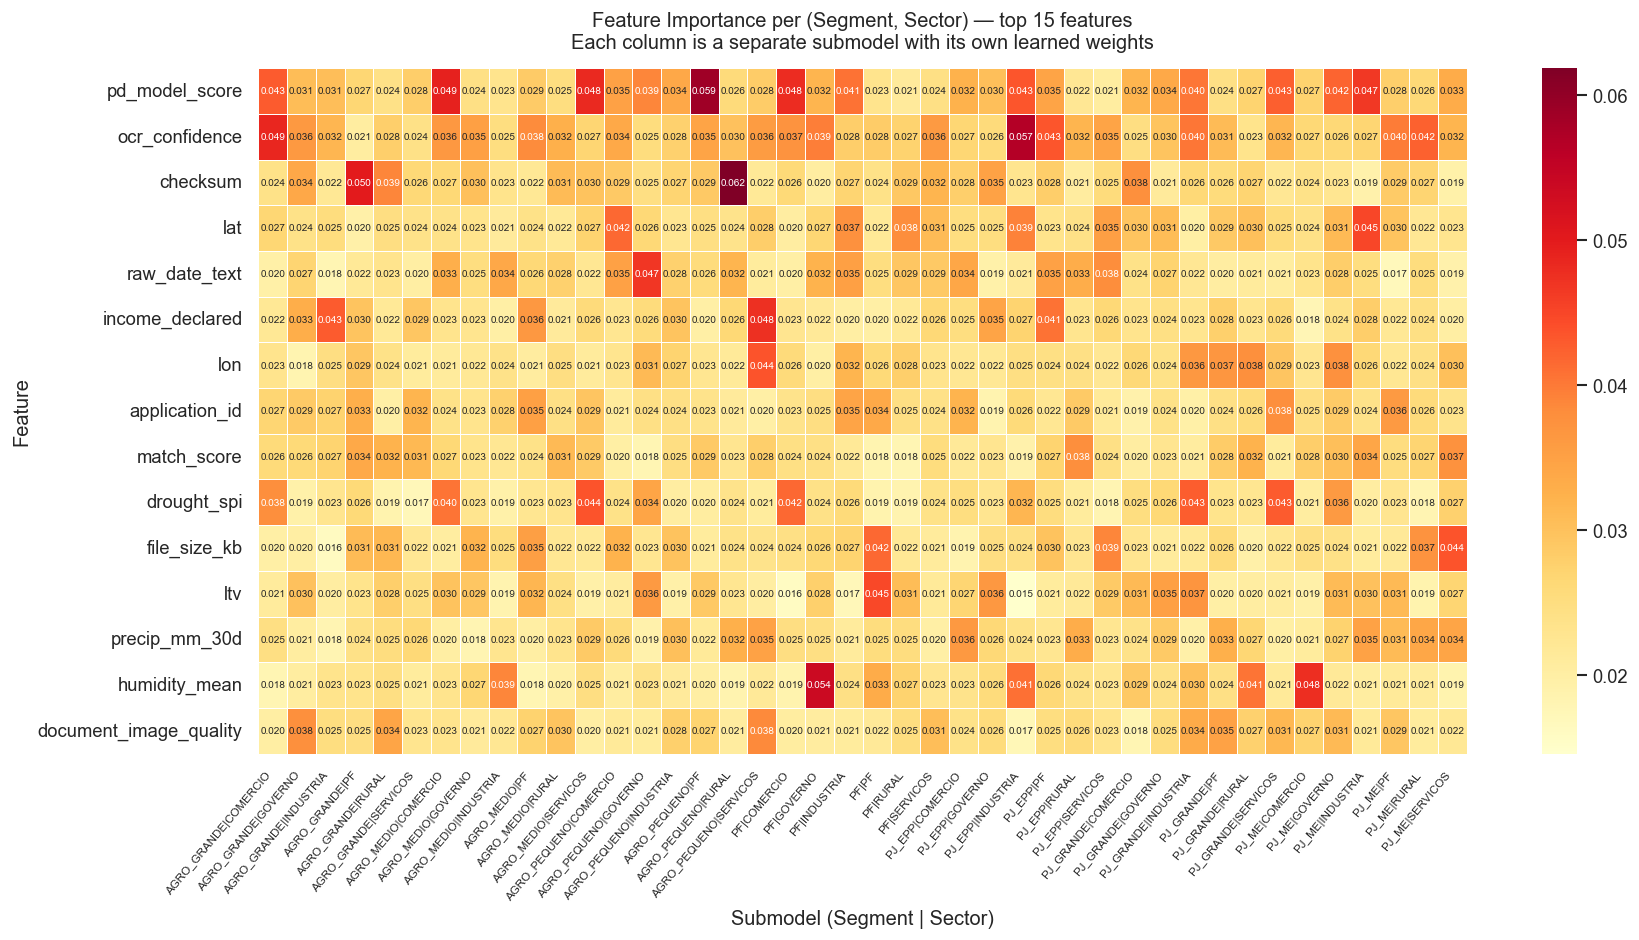

In [13]:
# Feature-importance matrix: rows = groups, cols = features
imp_df = pd.DataFrame(importances).T
imp_df.index = [f'{seg}|{sec}' for seg, sec in imp_df.index]

# Top 15 features by mean importance across all submodels
top15 = imp_df.mean().sort_values(ascending=False).head(15).index

fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(
    imp_df[top15].T,
    cmap='YlOrRd', ax=ax, linewidths=0.3,
    annot=True, fmt='.3f', annot_kws={'size': 6}
)
ax.set_title('Feature Importance per (Segment, Sector) — top 15 features\n'
             'Each column is a separate submodel with its own learned weights', pad=12)
ax.set_xlabel('Submodel (Segment | Sector)')
ax.set_ylabel('Feature')
plt.xticks(rotation=50, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

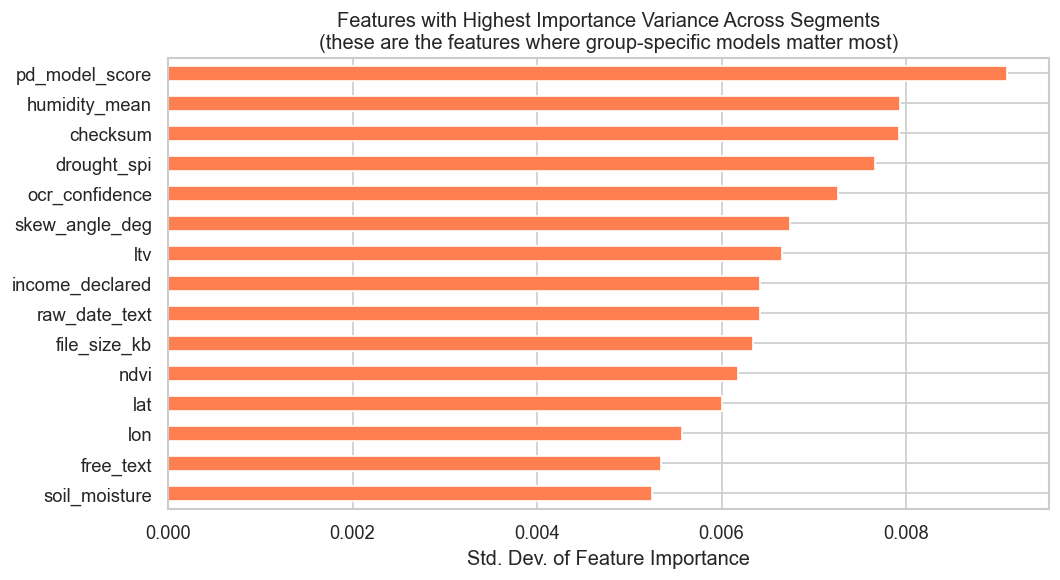

In [14]:
# Features whose importance varies MOST across segments
# High std = this feature is critical for some groups but irrelevant for others
imp_var = imp_df.std().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
imp_var.sort_values().plot(kind='barh', ax=ax, color='coral', edgecolor='white')
ax.set_title('Features with Highest Importance Variance Across Segments\n'
             '(these are the features where group-specific models matter most)')
ax.set_xlabel('Std. Dev. of Feature Importance')
plt.tight_layout()
plt.show()

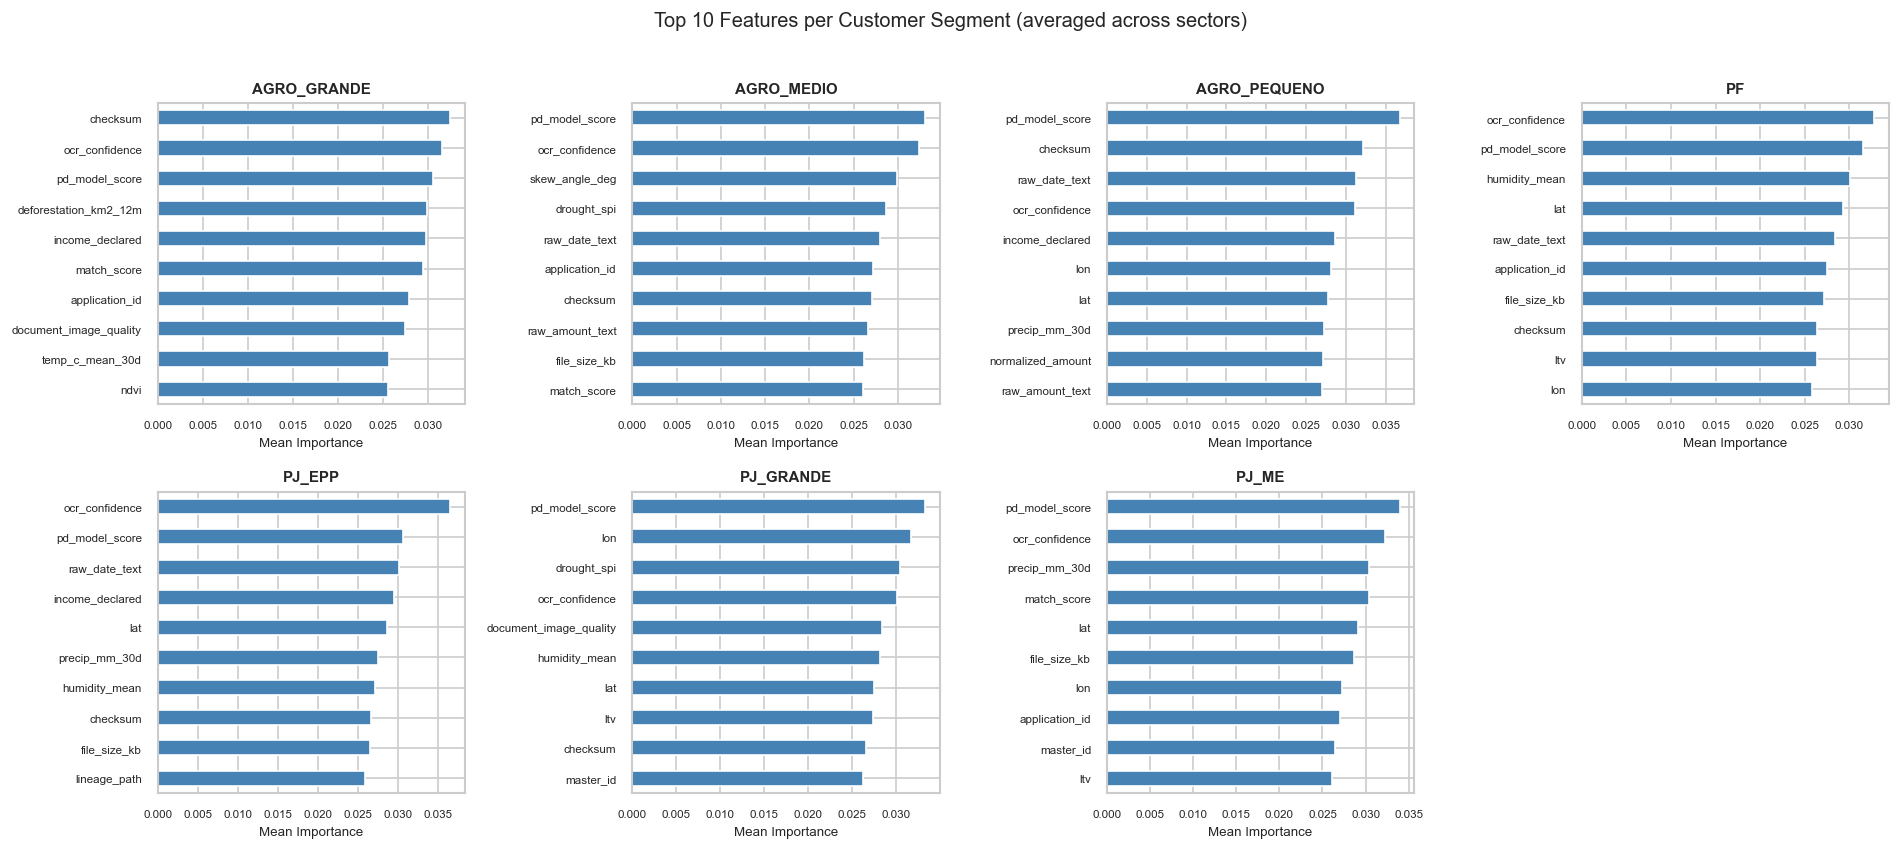

In [15]:
# Top 10 features per customer_segment (averaged across its sectors)
seg_imp = {}
for (seg, sec), imp in importances.items():
    seg_imp.setdefault(seg, []).append(imp)

segments = sorted(seg_imp.keys())
ncols = 4
nrows = int(np.ceil(len(segments) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, seg in enumerate(segments):
    mean_imp = pd.concat(seg_imp[seg], axis=1).mean(axis=1)
    top10 = mean_imp.sort_values(ascending=False).head(10).sort_values()
    top10.plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(seg, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Mean Importance', fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Top 10 Features per Customer Segment (averaged across sectors)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 7. Predict on New Data
A routing function that dispatches each row to its correct submodel.

In [16]:
def predict_segmented(df_new: pd.DataFrame) -> pd.DataFrame:
    """
    Accepts a raw DataFrame with the same schema as silver_databridge.csv
    (target column optional). Returns a copy with two added columns:
      - pred_default : 0 or 1
      - pred_proba   : probability of default (class 1)

    Rows whose (customer_segment, industry_sector) has no trained submodel
    are returned with NaN predictions.
    """
    df_out = df_new.copy()
    df_out['pred_default'] = np.nan
    df_out['pred_proba']   = np.nan

    # Encode the new data with the same fitted encoders
    df_enc = df_new.drop(columns=DROP_COLS + [TARGET] + GROUP_COLS, errors='ignore').copy()
    for col, le in encoders.items():
        if col in df_enc.columns:
            df_enc[col] = le.transform(df_enc[col].astype(str))

    for (seg, sec), rf in models.items():
        mask = (df_new['customer_segment'] == seg) & (df_new['industry_sector'] == sec)
        if mask.sum() == 0:
            continue
        X_new = df_enc.loc[mask, FEATURE_COLS]
        df_out.loc[mask, 'pred_default'] = rf.predict(X_new)
        df_out.loc[mask, 'pred_proba']   = rf.predict_proba(X_new)[:, 1]

    return df_out


# Sanity-check on a handful of rows
sample = df.drop(columns=[TARGET]).sample(8, random_state=7)
result = predict_segmented(sample)
result[['customer_segment', 'industry_sector', 'pred_default', 'pred_proba']].round(3)

,customer_segment,industry_sector,pred_default,pred_proba
1252,PJ_ME,PF,0.0,0.186
10444,AGRO_MEDIO,SERVICOS,0.0,0.171
8994,PJ_ME,COMERCIO,1.0,0.662
7463,AGRO_GRANDE,COMERCIO,0.0,0.237
1910,PJ_ME,COMERCIO,0.0,0.186
20606,AGRO_MEDIO,SERVICOS,0.0,0.150
9866,AGRO_PEQUENO,PF,0.0,0.138
3737,PJ_GRANDE,GOVERNO,0.0,0.201


## 8. Train GBM Global & RF Global (full feature set, including segment × sector)

In [17]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

# Encode ALL categoricals (including customer_segment and industry_sector)
DROP_FULL = [c for c in DROP_COLS if c in df.columns]
df_full = df.drop(columns=DROP_FULL).copy()

le_dict_full = {}
for col in df_full.select_dtypes(include=['object']).columns:
    if col == TARGET:
        continue
    le = LabelEncoder()
    df_full[col] = le.fit_transform(df_full[col].astype(str))
    le_dict_full[col] = le

target_full = df_full.pop(TARGET)
df_full = df_full.fillna(df_full.median(numeric_only=True))
feature_cols_full = df_full.columns.tolist()
medians_full = df_full.median().to_dict()
pd_q75 = float(df['pd_model_score'].quantile(0.75))

X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    df_full, target_full, test_size=0.2, random_state=42, stratify=target_full
)

gbm_global = HistGradientBoostingClassifier(
    max_iter=300, max_depth=4, learning_rate=0.05, random_state=42
)
gbm_global.fit(X_tr_f, y_tr_f)
gbm_proba_f = gbm_global.predict_proba(X_te_f)[:, 1]

rf_global_full = RandomForestClassifier(
    n_estimators=200, max_depth=8, random_state=42, n_jobs=-1
)
rf_global_full.fit(X_tr_f, y_tr_f)
rf_g_proba_f = rf_global_full.predict_proba(X_te_f)[:, 1]

importancias_full = pd.Series(
    rf_global_full.feature_importances_, index=feature_cols_full
).sort_values(ascending=False).head(15)

print(f'GBM Global  ROC-AUC: {roc_auc_score(y_te_f, gbm_proba_f):.4f}')
print(f'RF  Global  ROC-AUC: {roc_auc_score(y_te_f, rf_g_proba_f):.4f}')

GBM Global  ROC-AUC: 0.5718
RF  Global  ROC-AUC: 0.5724


In [18]:
# Evaluate segmented RF on the same global test split for a unified comparison
seg_col_te_f = df.iloc[X_te_f.index]['customer_segment'].values
sec_col_te_f = df.iloc[X_te_f.index]['industry_sector'].values

df_seg_eval = df.drop(columns=DROP_FULL + [TARGET], errors='ignore').copy()
for col, le_nb in encoders.items():
    if col in df_seg_eval.columns:
        known_vals = set(le_nb.classes_)
        s = df_seg_eval[col].astype(str)
        
        # 1. Get all unique values that the encoder actually knows
        valid_uniques = [v for v in s.unique() if v in known_vals]
        
        if valid_uniques:
            # 2. Transform them ALL AT ONCE (This is where you save minutes of compute time)
            transformed_vals = le_nb.transform(valid_uniques)
            
            # 3. Zip them back into a dictionary
            mapping = dict(zip(valid_uniques, transformed_vals))
            
            # 4. Map to the dataframe
            df_seg_eval[col] = s.map(mapping).fillna(0).astype(int)
        else:
            # If no known values exist in this split, just fill with 0
            df_seg_eval[col] = 0

X_seg_te_f = df_seg_eval.iloc[X_te_f.index][FEATURE_COLS].values
all_proba_br_f = np.zeros(len(X_te_f))

for (seg_val, sec_val), rf_nb in models.items():
    mask = (seg_col_te_f == seg_val) & (sec_col_te_f == sec_val)
    if mask.sum() == 0:
        continue
    all_proba_br_f[mask] = rf_nb.predict_proba(X_seg_te_f[mask])[:, 1]

mask_any_f  = all_proba_br_f > 0
br_proba_f  = all_proba_br_f[mask_any_f]
br_target_f = y_te_f.values[mask_any_f]

seg_metricas_export = {}
for seg_val in df['customer_segment'].unique():
    mask_s = seg_col_te_f == seg_val
    y_s = y_te_f.values[mask_s]
    p_s = all_proba_br_f[mask_s]
    if len(y_s) > 10 and y_s.sum() > 1 and p_s.sum() > 0:
        seg_metricas_export[seg_val] = {
            'roc': round(roc_auc_score(y_s, p_s), 4),
            'pr':  round(average_precision_score(y_s, p_s), 4),
            'n':   int(mask_s.sum()),
        }

metricas_export = {
    'GBM Global': {
        'roc': round(roc_auc_score(y_te_f, gbm_proba_f), 4),
        'pr':  round(average_precision_score(y_te_f, gbm_proba_f), 4),
    },
    'RF Global': {
        'roc': round(roc_auc_score(y_te_f, rf_g_proba_f), 4),
        'pr':  round(average_precision_score(y_te_f, rf_g_proba_f), 4),
    },
    'RF Segmentado': {
        'roc': round(roc_auc_score(br_target_f, br_proba_f), 4) if br_proba_f.size else 0,
        'pr':  round(average_precision_score(br_target_f, br_proba_f), 4) if br_proba_f.size else 0,
    },
}

def sample_roc(fpr, tpr, n=60):
    idx = np.linspace(0, len(fpr) - 1, n, dtype=int)
    return fpr[idx].tolist(), tpr[idx].tolist()

roc_curves_export = {}
for label, proba_e, tgt_e in [
    ('GBM Global',    gbm_proba_f,  y_te_f.values),
    ('RF Global',     rf_g_proba_f, y_te_f.values),
    ('RF Segmentado', br_proba_f,   br_target_f),
]:
    if len(proba_e):
        fpr_e, tpr_e, _ = roc_curve(tgt_e, proba_e)
        roc_curves_export[label] = sample_roc(fpr_e, tpr_e)

print('Métricas exportadas:')
for k, v in metricas_export.items():
    print(f'  {k}: ROC={v["roc"]:.4f}, PR={v["pr"]:.4f}')

Métricas exportadas:
  GBM Global: ROC=0.5718, PR=0.2121
  RF Global: ROC=0.5724, PR=0.2151
  RF Segmentado: ROC=0.9492, PR=0.9061


In [19]:
import joblib, pathlib
from concurrent.futures import ThreadPoolExecutor

_nb_dir    = pathlib.Path(__file__).parent if '__file__' in dir() else pathlib.Path.cwd()
_root_dir  = (_nb_dir / '..').resolve() if _nb_dir.name == 'notebooks' else _nb_dir
models_dir = _root_dir / 'models'
models_dir.mkdir(parents=True, exist_ok=True)
(models_dir / 'seg').mkdir(exist_ok=True)

seg_medians = {col: float(df_clean[col].median()) for col in FEATURE_COLS if col in df_clean.columns}

# Build a flat list of (object, path) pairs — global artifacts + 42 submodels
_to_dump = [
    ({'model': gbm_global, 'le_dict': le_dict_full, 'feature_cols': feature_cols_full,
      'drop_cols': DROP_FULL, 'medians': medians_full, 'pd_score_q75': pd_q75},
     models_dir / 'gbm_global.joblib'),

    ({'model': rf_global_full, 'importancias': importancias_full},
     models_dir / 'rf_global.joblib'),

    ({'metricas': metricas_export, 'seg_metricas': seg_metricas_export,
      'roc_curves': roc_curves_export},
     models_dir / 'metrics.joblib'),

    ({'encoders': encoders, 'feature_cols': FEATURE_COLS,
      'drop_cols': DROP_FULL, 'medians': seg_medians},
     models_dir / 'seg_artifacts.joblib'),
] + [
    (rf_model, models_dir / 'seg' / f'{seg}_{sec}.joblib')
    for (seg, sec), rf_model in models.items()
]

def _dump(args):
    obj, path = args
    joblib.dump(obj, path)

with ThreadPoolExecutor() as pool:
    list(pool.map(_dump, _to_dump))

print(f'Exported {len(_to_dump)} files to {models_dir}:')
for fname in ['gbm_global.joblib', 'rf_global.joblib', 'metrics.joblib', 'seg_artifacts.joblib']:
    size = (models_dir / fname).stat().st_size / 1e6
    print(f'  {fname:<25} {size:.1f} MB')
print(f'  seg/ ({len(models)} submodels)')

Exported 46 files to /home/paolot/Workspace/BB_data_analysis/models:
  gbm_global.joblib         5.3 MB
  rf_global.joblib          3.4 MB
  metrics.joblib            0.0 MB
  seg_artifacts.joblib      5.2 MB
  seg/ (42 submodels)
